# Deep-SSFS — Notebook 3: Interpretability & Results


## 1. Environment Setup

In [ ]:
!pip install -q seaborn

In [ ]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import mnist, fashion_mnist

RESULTS_DIR = './results/'
os.makedirs(RESULTS_DIR, exist_ok=True)

FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("All imports successful.")

All imports successful.


## 2. Final Selected Feature Indices (10,000 Samples)


```python
with open('./results/DeepSSFS_MNIST_10000samples_<ts>.json') as f:
    data = json.load(f)
deep_mnist = data['MNIST_10000']['selected_features']
```

In [ ]:

# MNIST — Deep-SSFS selected pixels (ordered by importance)
deep_mnist = [
    736, 738, 686, 712, 682, 628, 77, 744, 684, 240,
    435, 157, 126, 130, 236, 575, 155, 709, 405, 680,
    661, 125, 131, 349, 655, 620, 549, 473, 545, 487,
    573, 129, 182, 517, 152, 768, 688, 269, 602, 659,
    451, 408, 743, 340, 658, 322, 214, 432, 297, 183
]

# MNIST — Classic-SSFS / XGBoost baseline selected pixels
xgb_mnist = [
    99, 690, 386, 742, 555, 740, 248, 358, 556, 71,
    657, 100, 219, 738, 713, 741, 601, 247, 578, 322,
    96, 102, 156, 737, 656, 567, 689, 538, 743, 692,
    539, 712, 739, 564, 597, 155, 563, 658, 628, 693,
    527, 714, 744, 583, 546, 568, 376, 350, 179, 178
]

# Fashion-MNIST — Deep-SSFS selected pixels
deep_fmnist = [
    77, 721, 11, 766, 9, 73, 317, 42, 437, 760,
    420, 375, 454, 17, 47, 665, 118, 174, 10, 18,
    46, 16, 486, 340, 619, 404, 752, 494, 14, 547,
    103, 410, 327, 593, 353, 443, 121, 741, 405, 464,
    376, 201, 708, 488, 439, 238, 293, 759, 446, 214
]

# Fashion-MNIST — Classic-SSFS / XGBoost baseline selected pixels
xgb_fmnist = [
    309, 627, 365, 346, 117, 337, 490, 368, 628, 281,
    224, 145, 196, 722, 655, 118, 471, 90, 465, 341,
    387, 705, 340, 252, 468, 178, 437, 599, 207, 342,
    229, 536, 464, 280, 508, 613, 555, 173, 314, 694,
    254, 732, 481, 179, 751, 369, 723, 499, 201, 470
]

print(f"MNIST     — Deep-SSFS: {len(deep_mnist)} features,  XGBoost: {len(xgb_mnist)} features")
print(f"Fashion-MNIST — Deep-SSFS: {len(deep_fmnist)} features,  XGBoost: {len(xgb_fmnist)} features")


def load_features_from_json(json_path, bench_key):
    """Optional helper: load selected_features from a Notebook 2 JSON output."""
    with open(json_path) as fh:
        data = json.load(fh)
    return data[bench_key]['selected_features']

MNIST     — Deep-SSFS: 50 features,  XGBoost: 50 features
Fashion-MNIST — Deep-SSFS: 50 features,  XGBoost: 50 features


## 3. Jaccard Index — Feature Set Overlap

The Jaccard Similarity Index measures the ratio of the intersection to the union of the two feature sets:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

A low Jaccard score indicates that the two methods have discovered complementary feature subsets, suggesting the deep surrogate captures structure that the XGBoost baseline misses.

MNIST         — Shared pixels:  8  |  Jaccard: 8.70%
Fashion-MNIST — Shared pixels:  5  |  Jaccard: 5.26%
Saved: jaccard_overlap_bar.png


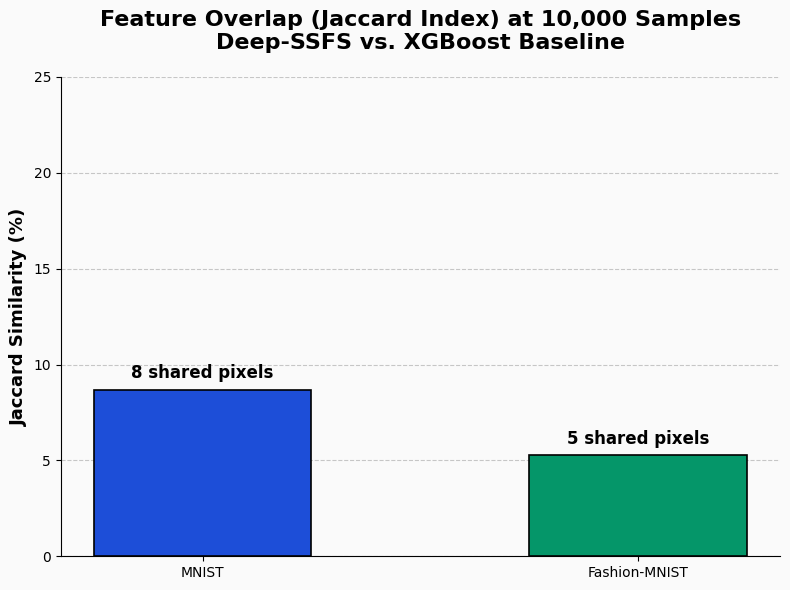

In [ ]:
def calc_jaccard(list1, list2):
    """Compute Jaccard similarity between two feature index lists."""
    s1, s2       = set(list1), set(list2)
    intersection = len(s1 & s2)
    union        = len(s1 | s2)
    return intersection, (intersection / union) * 100


intersect_mnist,  jaccard_mnist  = calc_jaccard(deep_mnist,  xgb_mnist)
intersect_fmnist, jaccard_fmnist = calc_jaccard(deep_fmnist, xgb_fmnist)

print(f"MNIST         — Shared pixels: {intersect_mnist:>2}  |  Jaccard: {jaccard_mnist:.2f}%")
print(f"Fashion-MNIST — Shared pixels: {intersect_fmnist:>2}  |  Jaccard: {jaccard_fmnist:.2f}%")

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

datasets       = ['MNIST', 'Fashion-MNIST']
jaccard_scores = [jaccard_mnist, jaccard_fmnist]
intersections  = [intersect_mnist, intersect_fmnist]
colors         = ['#1D4ED8', '#059669']

bars = ax.bar(datasets, jaccard_scores, color=colors, width=0.5,
              edgecolor='black', linewidth=1.2, zorder=3)

for bar, n_shared in zip(bars, intersections):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{n_shared} shared pixels",
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title(
    'Feature Overlap (Jaccard Index) at 10,000 Samples\nDeep-SSFS vs. XGBoost Baseline',
    fontsize=16, fontweight='bold', pad=20
)
ax.set_ylabel('Jaccard Similarity (%)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 25)
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'jaccard_overlap_bar.png'), dpi=300, bbox_inches='tight')
print("Saved: jaccard_overlap_bar.png")
plt.show()

## 4. Rank-Based Pixel Importance Heatmaps



Saved: ./results/ranked_pixel_heatmaps.png


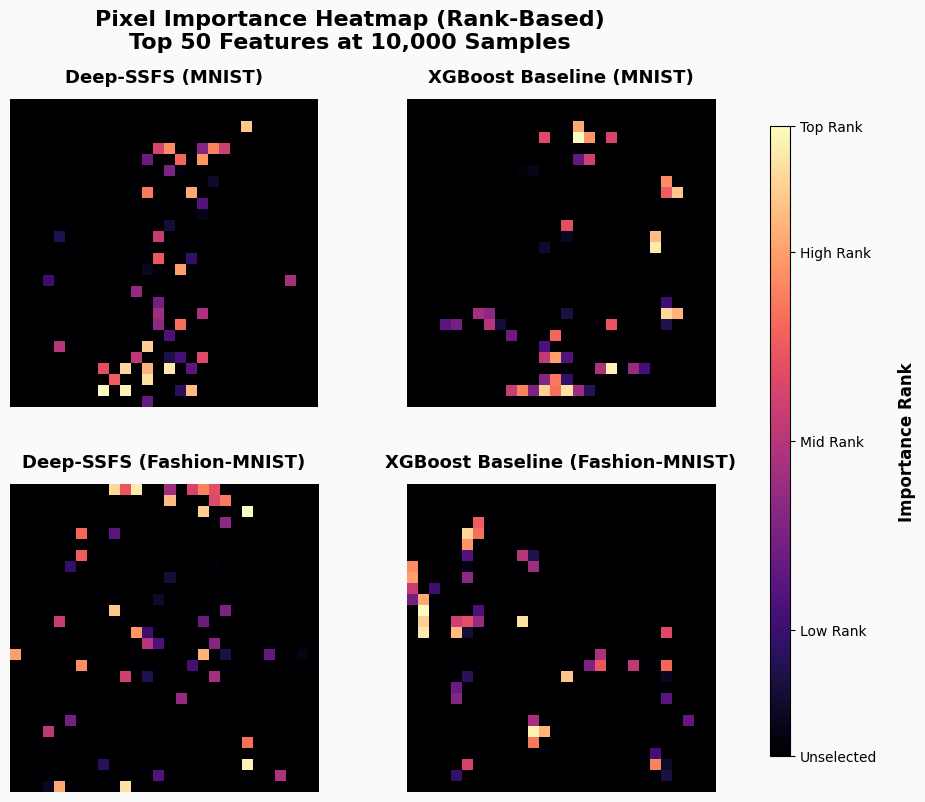

In [ ]:
def plot_ranked_heatmaps(deep_mnist, xgb_mnist, deep_fmnist, xgb_fmnist,
                          save_path=None):
    """
    2×2 grid of rank-based pixel importance heatmaps.
    Top row: MNIST. Bottom row: Fashion-MNIST.
    Left column: Deep-SSFS. Right column: XGBoost baseline.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 9), facecolor='#FAFAFA')
    fig.suptitle(
        "Pixel Importance Heatmap (Rank-Based)\nTop 50 Features at 10,000 Samples",
        fontsize=16, fontweight='bold', y=0.98
    )

    panel_data = [
        (deep_mnist,  "Deep-SSFS (MNIST)"),
        (xgb_mnist,   "XGBoost Baseline (MNIST)"),
        (deep_fmnist, "Deep-SSFS (Fashion-MNIST)"),
        (xgb_fmnist,  "XGBoost Baseline (Fashion-MNIST)"),
    ]

    for ax, (indices, title) in zip(axes.flatten(), panel_data):
        canvas = np.zeros(784)
        for rank, pixel_idx in enumerate(indices):
            canvas[pixel_idx] = len(indices) - rank   # rank 1 → highest score
        img_2d = (canvas / len(indices)).reshape(28, 28)

        cax = ax.imshow(img_2d, cmap='magma', interpolation='nearest')
        ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
        ax.axis('off')

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar    = fig.colorbar(cax, cax=cbar_ax)
    cbar.set_ticks([0, 0.2, 0.5, 0.8, 1.0])
    cbar.set_ticklabels(['Unselected', 'Low Rank', 'Mid Rank', 'High Rank', 'Top Rank'])
    cbar.set_label('Importance Rank', fontsize=12, fontweight='bold', labelpad=15)

    plt.subplots_adjust(wspace=0.05, hspace=0.25, right=0.90)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_ranked_heatmaps(
    deep_mnist, xgb_mnist, deep_fmnist, xgb_fmnist,
    save_path=os.path.join(RESULTS_DIR, 'ranked_pixel_heatmaps.png')
)

## 5. Comparative Per-Class Overlays



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Saved: ./results/mnist_comparison_overlay.png


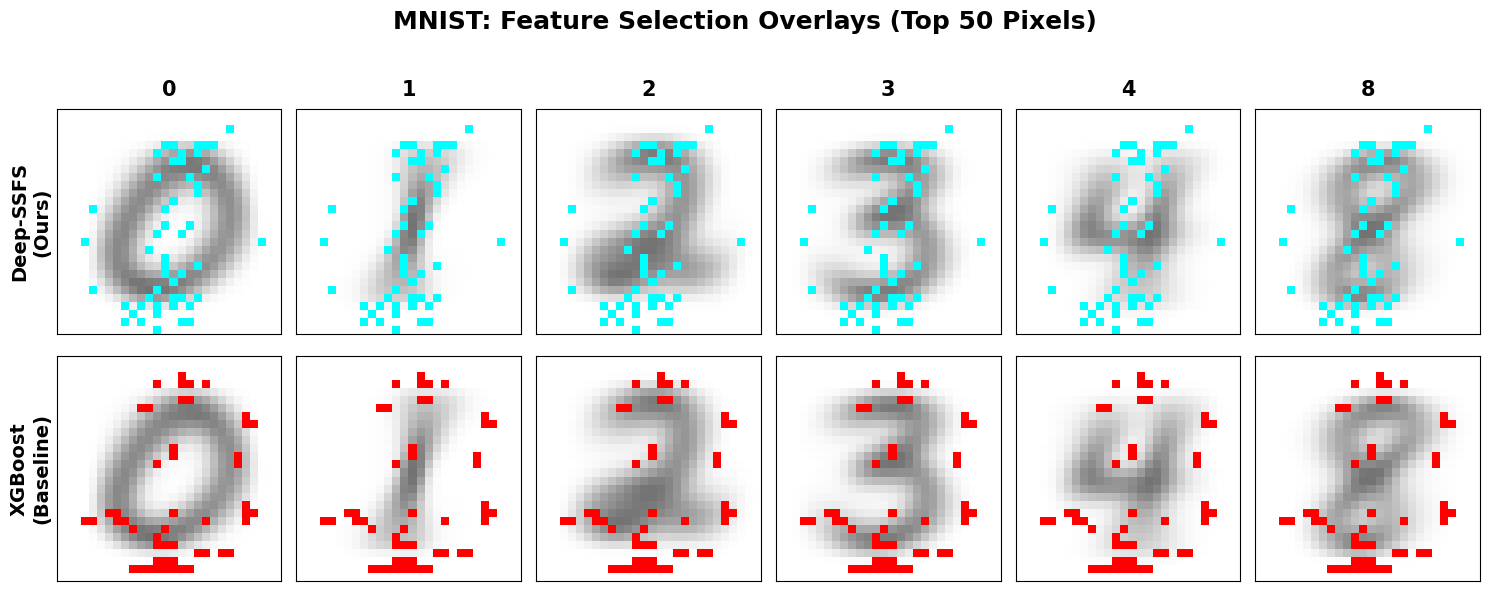

Saved: ./results/fmnist_comparison_overlay.png


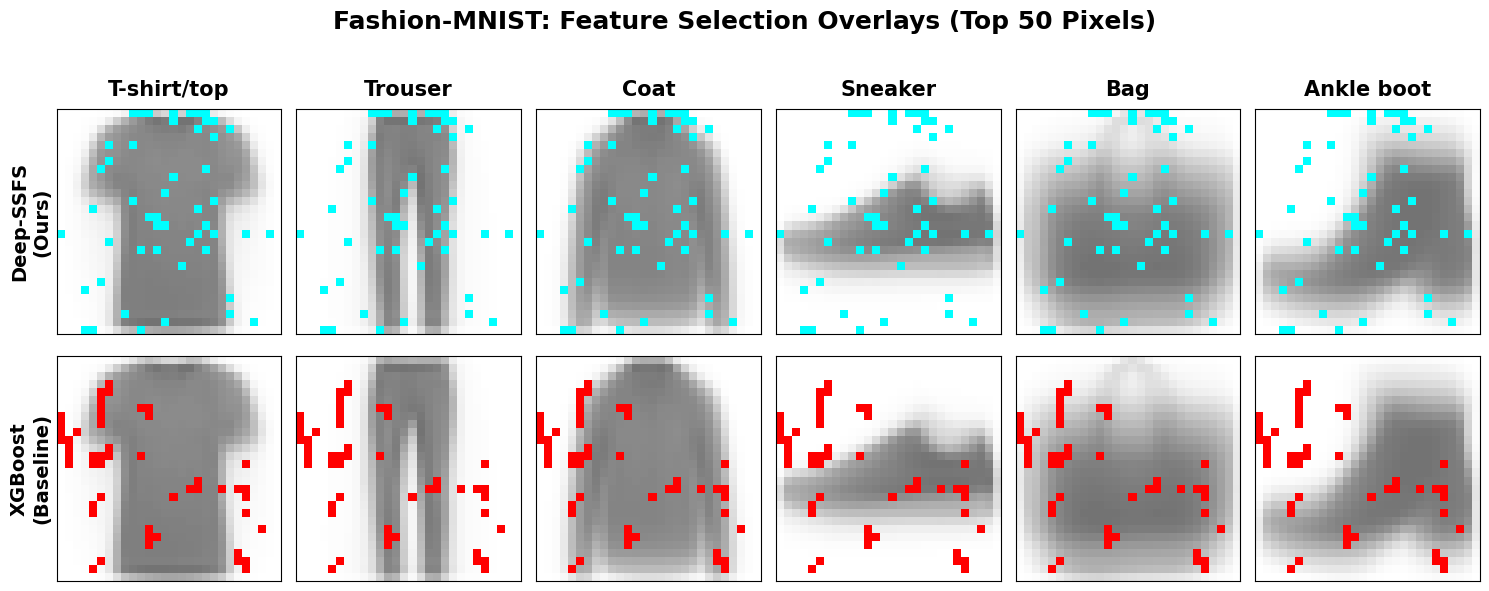

In [ ]:
(X_mnist_raw, y_mnist), _  = mnist.load_data()
(X_fmnist_raw, y_fmnist), _ = fashion_mnist.load_data()


def plot_comparative_overlays(X_data, y_data, deep_idx, xgb_idx,
                               dataset_name, classes_to_plot,
                               class_labels=None, save_path=None):
    """
    Two-row grid: Row 0 = Deep-SSFS overlay, Row 1 = XGBoost overlay.
    Columns correspond to selected classes.
    """
    n_cols = len(classes_to_plot)
    fig, axes = plt.subplots(2, n_cols, figsize=(2.5 * n_cols, 6))
    fig.suptitle(
        f"{dataset_name}: Feature Selection Overlays (Top 50 Pixels)",
        fontsize=18, fontweight='bold', y=1.02
    )

    mask_deep = np.zeros(784);  mask_deep[deep_idx] = 1
    mask_xgb  = np.zeros(784);  mask_xgb[xgb_idx]  = 1
    overlay_deep = np.ma.masked_where(mask_deep.reshape(28, 28) == 0,
                                       mask_deep.reshape(28, 28))
    overlay_xgb  = np.ma.masked_where(mask_xgb.reshape(28, 28)  == 0,
                                       mask_xgb.reshape(28, 28))

    for col, cls in enumerate(classes_to_plot):
        avg_img = np.mean(X_data[y_data == cls], axis=0)   # mean class silhouette
        label   = class_labels[col] if class_labels else str(cls)

        ax_d = axes[0, col]
        ax_d.imshow(avg_img, cmap='gray_r', alpha=0.55)
        ax_d.imshow(overlay_deep, cmap='cool', interpolation='nearest', alpha=1.0)
        if col == 0:
            ax_d.set_ylabel("Deep-SSFS\n(Ours)", fontsize=14, fontweight='bold')
        ax_d.set_title(label, fontsize=15, fontweight='bold', pad=10)
        ax_d.set_xticks([]); ax_d.set_yticks([])

        ax_x = axes[1, col]
        ax_x.imshow(avg_img, cmap='gray_r', alpha=0.55)
        ax_x.imshow(overlay_xgb, cmap='autumn', interpolation='nearest', alpha=1.0)
        if col == 0:
            ax_x.set_ylabel("XGBoost\n(Baseline)", fontsize=14, fontweight='bold')
        ax_x.set_xticks([]); ax_x.set_yticks([])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_comparative_overlays(
    X_mnist_raw, y_mnist, deep_mnist, xgb_mnist,
    "MNIST", classes_to_plot=[0, 1, 2, 3, 4, 8],
    save_path=os.path.join(RESULTS_DIR, 'mnist_comparison_overlay.png')
)

fmnist_subset   = [0, 1, 4, 7, 8, 9]
fmnist_labels_s = [FASHION_LABELS[i] for i in fmnist_subset]
plot_comparative_overlays(
    X_fmnist_raw, y_fmnist, deep_fmnist, xgb_fmnist,
    "Fashion-MNIST", classes_to_plot=fmnist_subset, class_labels=fmnist_labels_s,
    save_path=os.path.join(RESULTS_DIR, 'fmnist_comparison_overlay.png')
)

## 6.Overlap Scatter Plot (Fashion-MNIST)



Saved: ./results/fmnist_overlap_scatter.png


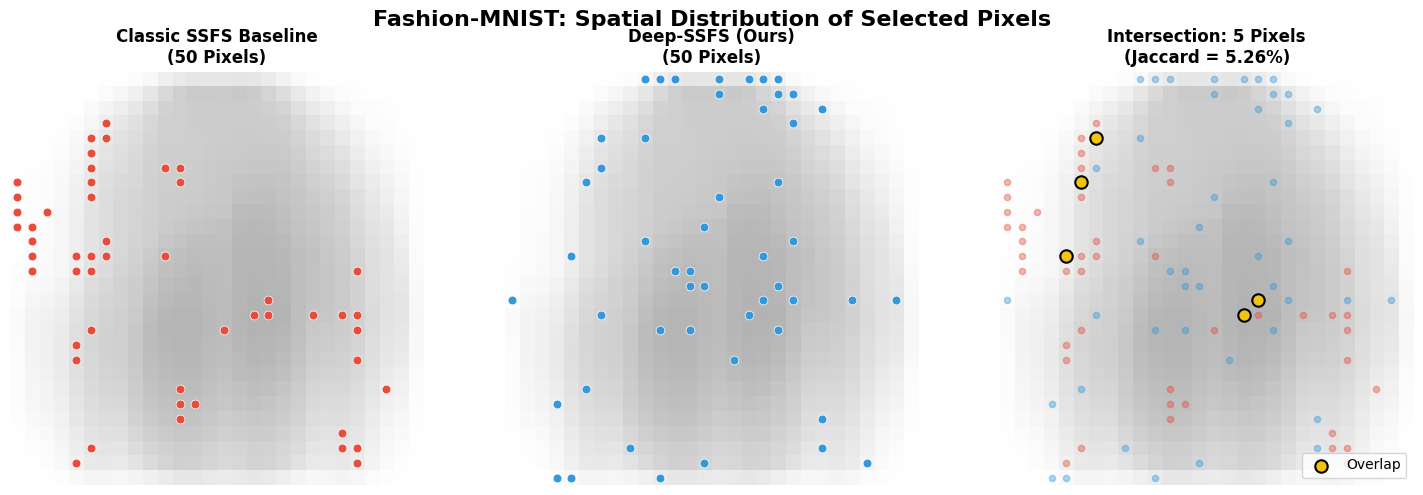

Saved: ./results/mnist_overlap_scatter.png


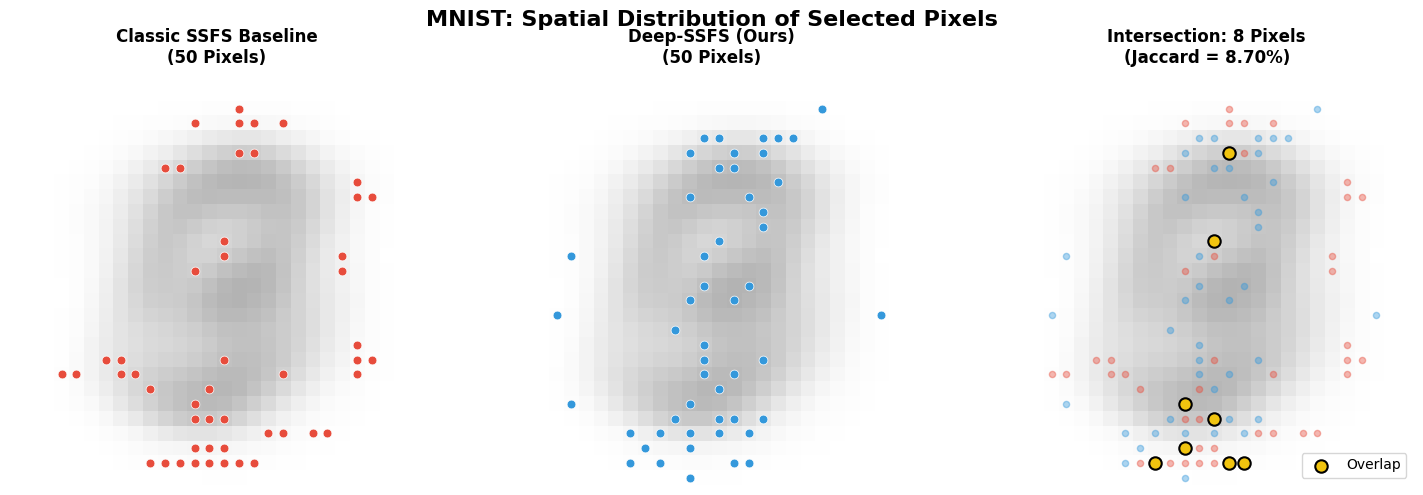

In [ ]:
def get_coords(indices):
    """Convert flat 784-dim pixel indices to (col, row) 28×28 coordinates."""
    idx = np.array(indices)
    return idx % 28, idx // 28


def plot_overlap_scatter(X_data, deep_idx, classic_idx, dataset_name,
                          save_path=None):
    """
    Three-panel figure: Classic only | Deep only | Intersection overlay.
    """
    mean_img   = np.mean(X_data, axis=0).reshape(28, 28)
    set_deep   = set(deep_idx)
    set_classic = set(classic_idx)
    overlap    = np.array(list(set_deep & set_classic))

    c_x, c_y = get_coords(classic_idx)
    d_x, d_y = get_coords(deep_idx)

    jaccard_pct = len(set_deep & set_classic) / len(set_deep | set_classic) * 100

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"{dataset_name}: Spatial Distribution of Selected Pixels",
        fontsize=16, fontweight='bold'
    )

    for ax, xs, ys, color, title in [
        (ax1, c_x, c_y, '#e74c3c', 'Classic SSFS Baseline\n(50 Pixels)'),
        (ax2, d_x, d_y, '#3498db', 'Deep-SSFS (Ours)\n(50 Pixels)'),
    ]:
        ax.imshow(mean_img, cmap='gray_r', alpha=0.3)
        ax.scatter(xs, ys, c=color, s=40, edgecolors='white', linewidths=0.5)
        ax.set_title(title, fontweight='bold')
        ax.axis('off')

    # Panel 3: full overlap
    ax3.imshow(mean_img, cmap='gray_r', alpha=0.3)
    ax3.scatter(c_x, c_y, c='#e74c3c', s=20, alpha=0.4)
    ax3.scatter(d_x, d_y, c='#3498db', s=20, alpha=0.4)
    if len(overlap) > 0:
        o_x, o_y = get_coords(overlap)
        ax3.scatter(o_x, o_y, c='#f1c40f', s=80, label='Overlap',
                    edgecolors='black', linewidths=1.5, zorder=5)
    ax3.set_title(
        f"Intersection: {len(overlap)} Pixels\n(Jaccard = {jaccard_pct:.2f}%)",
        fontweight='bold'
    )
    ax3.legend(loc='lower right')
    ax3.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_overlap_scatter(
    X_fmnist_raw.reshape(-1, 784), deep_fmnist, xgb_fmnist,
    "Fashion-MNIST",
    save_path=os.path.join(RESULTS_DIR, 'fmnist_overlap_scatter.png')
)

plot_overlap_scatter(
    X_mnist_raw.reshape(-1, 784), deep_mnist, xgb_mnist,
    "MNIST",
    save_path=os.path.join(RESULTS_DIR, 'mnist_overlap_scatter.png')
)

## 7. Individual Sample Investigation (Fashion-MNIST)



Saved: ./results/fmnist_individual_investigation.png


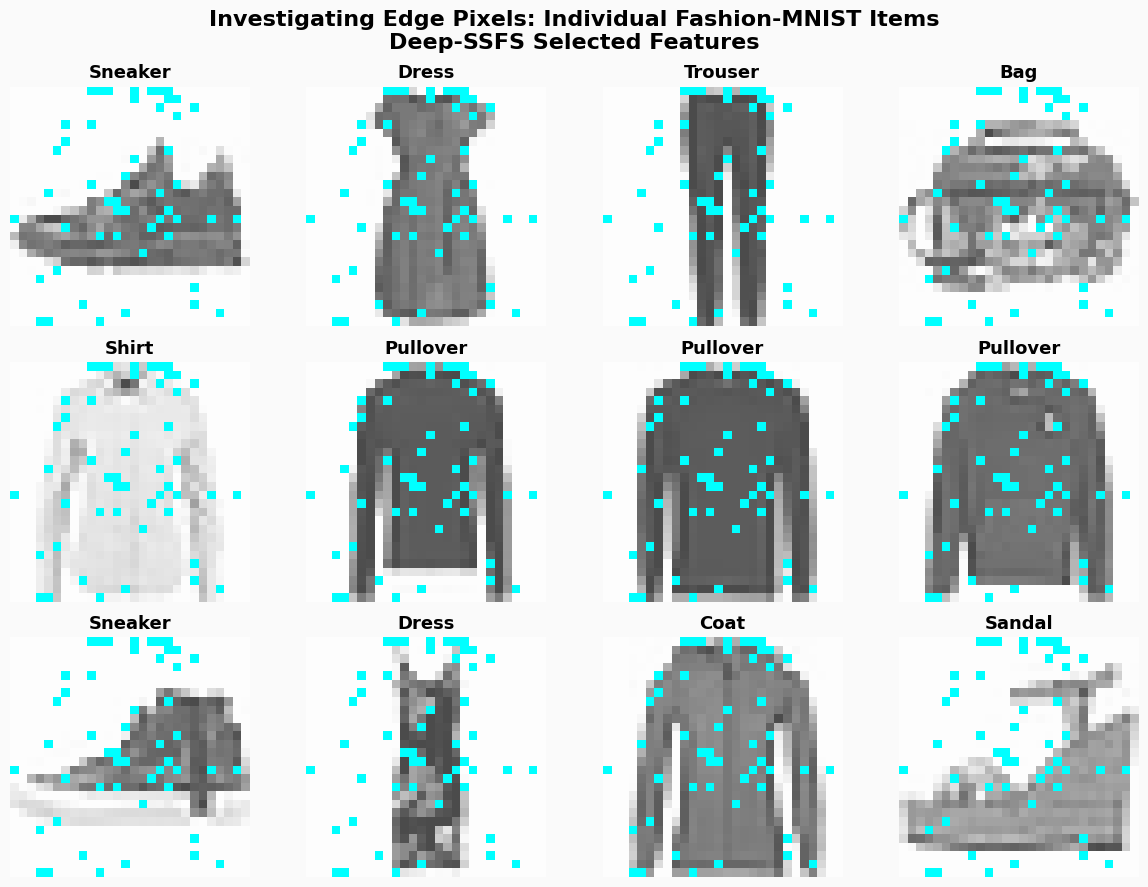

In [ ]:
def plot_individual_investigation(X_data, y_data, selected_idx,
                                   class_labels, n_samples=12, seed=42,
                                   save_path=None):
    """
    Overlay selected pixels on `n_samples` randomly chosen real images.
    Demonstrates feature relevance beyond class averages.
    """
    mask_2d = np.zeros(784)
    mask_2d[selected_idx] = 1
    overlay = np.ma.masked_where(mask_2d.reshape(28, 28) == 0,
                                  mask_2d.reshape(28, 28))

    rng  = np.random.default_rng(seed)
    idxs = rng.choice(len(X_data), n_samples, replace=False)

    n_rows = int(np.ceil(n_samples / 4))
    fig, axes = plt.subplots(n_rows, 4, figsize=(12, 3 * n_rows), facecolor='#FAFAFA')
    fig.suptitle(
        "Investigating Edge Pixels: Individual Fashion-MNIST Items\nDeep-SSFS Selected Features",
        fontsize=16, fontweight='bold', y=0.98
    )

    for i, ax in enumerate(axes.flatten()):
        if i >= n_samples:
            ax.axis('off')
            continue
        img_idx = idxs[i]
        ax.imshow(X_data[img_idx], cmap='gray_r', alpha=0.7)
        ax.imshow(overlay, cmap='cool', interpolation='nearest', alpha=1.0)
        ax.set_title(class_labels[y_data[img_idx]], fontsize=13, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_individual_investigation(
    X_fmnist_raw, y_fmnist, deep_fmnist,
    class_labels={i: FASHION_LABELS[i] for i in range(10)},
    save_path=os.path.join(RESULTS_DIR, 'fmnist_individual_investigation.png')
)

## 8. Learning Curves — The 'Data Hunger' Effect



Saved: ./results/mnist_learning_curve.png


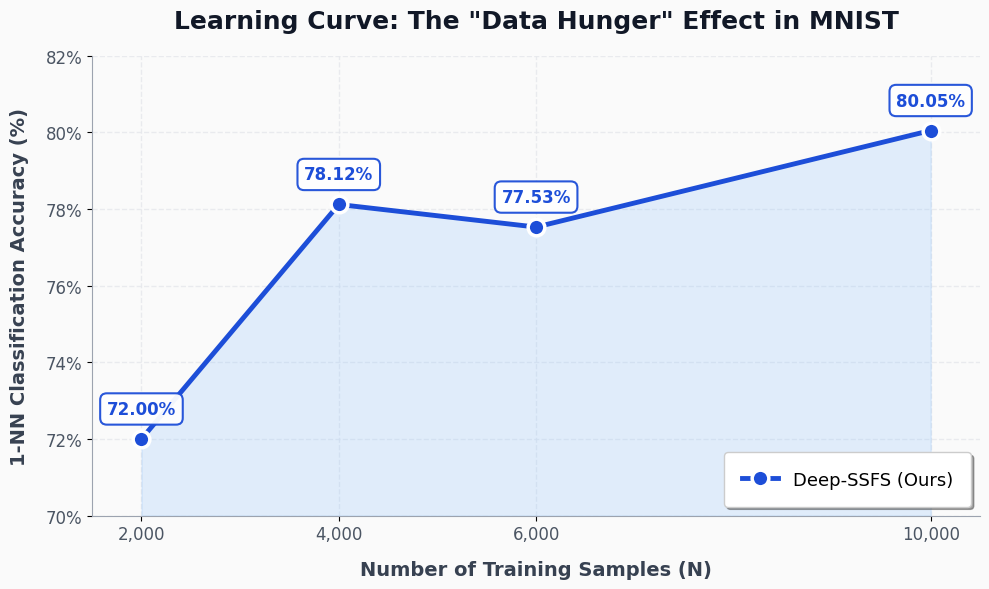

Saved: ./results/fmnist_learning_curve.png


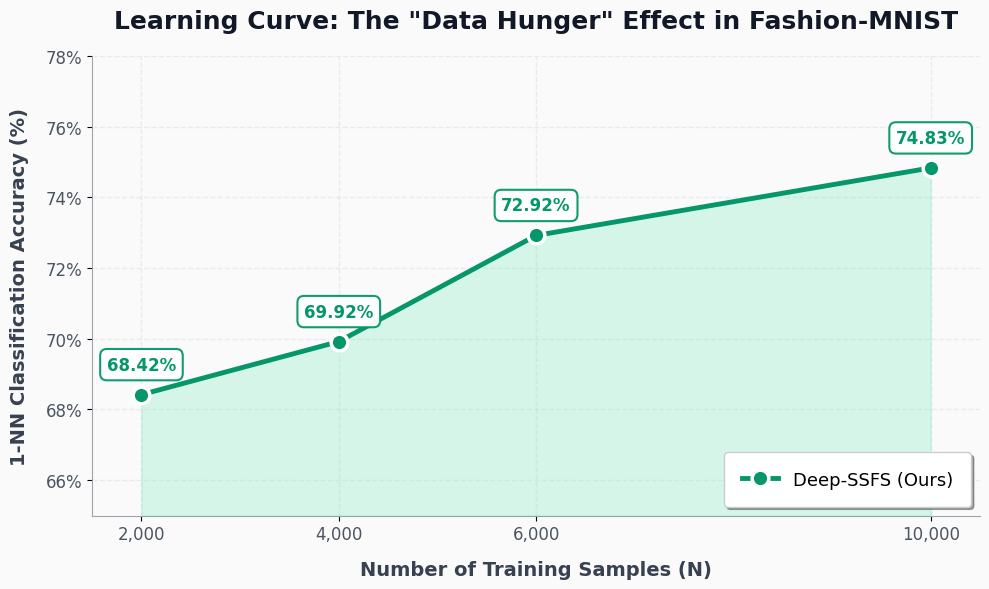

In [ ]:

SAMPLE_SIZES = [2000, 4000, 6000, 10000]

# MNIST
MNIST_DEEP_ACC    = [0.7200, 0.7812, 0.7753, 0.8005]

# Fashion-MNIST
FMNIST_DEEP_ACC   = [0.6842, 0.6992, 0.7292, 0.7483]


def plot_learning_curve(sample_sizes, accuracies, dataset_name,
                         line_color, fill_color, y_min, y_max,
                         save_path=None):
    """
    Polished learning curve with annotated data points and shaded fill.
    """
    acc_pct = [a * 100 for a in accuracies]

    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    ax.plot(sample_sizes, acc_pct, color=line_color, linewidth=3.5,
            marker='o', markersize=12,
            markeredgecolor='white', markeredgewidth=2.5,
            label='Deep-SSFS (Ours)', zorder=3)
    ax.fill_between(sample_sizes, acc_pct, y_min,
                    color=fill_color, alpha=0.25, zorder=2)

    ax.set_title(
        f'Learning Curve: The "Data Hunger" Effect in {dataset_name}',
        fontsize=18, fontweight='bold', pad=20, color='#111827'
    )
    ax.set_xlabel('Number of Training Samples (N)',
                  fontsize=14, fontweight='bold', color='#374151', labelpad=12)
    ax.set_ylabel('1-NN Classification Accuracy (%)',
                  fontsize=14, fontweight='bold', color='#374151', labelpad=12)

    ax.set_ylim(y_min, y_max)
    ax.set_xlim(1500, 10500)
    ax.set_xticks(sample_sizes)
    ax.set_xticklabels([f"{x:,}" for x in sample_sizes], fontsize=12, color='#4B5563')
    ax.set_yticklabels([f"{int(y)}%" for y in ax.get_yticks()], fontsize=12, color='#4B5563')

    ax.grid(True, linestyle='--', linewidth=1, color='#E5E7EB', alpha=0.8, zorder=1)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color('#9CA3AF')
    ax.spines['bottom'].set_color('#9CA3AF')

    for n, a in zip(sample_sizes, accuracies):
        ax.annotate(
            f"{a:.2%}",
            (n, a * 100),
            textcoords='offset points', xytext=(0, 18),
            ha='center', fontsize=12, fontweight='bold', color=line_color,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=line_color,
                      lw=1.5, alpha=0.95),
            zorder=4
        )

    ax.legend(fontsize=13, loc='lower right', frameon=True, shadow=True, borderpad=1)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_learning_curve(
    SAMPLE_SIZES, MNIST_DEEP_ACC, 'MNIST',
    line_color='#1D4ED8', fill_color='#93C5FD',
    y_min=70, y_max=82,
    save_path=os.path.join(RESULTS_DIR, 'mnist_learning_curve.png')
)

plot_learning_curve(
    SAMPLE_SIZES, FMNIST_DEEP_ACC, 'Fashion-MNIST',
    line_color='#059669', fill_color='#6EE7B7',
    y_min=65, y_max=78,
    save_path=os.path.join(RESULTS_DIR, 'fmnist_learning_curve.png')
)

## 10. Confusion Matrix — Fashion-MNIST (10K, Deep-SSFS)

A normalised confusion matrix showing per-class prediction rates for the 1-NN classifier trained on the 50 Deep-SSFS selected features at 10,000 training samples.

Fitting 1-NN classifier on 10K Fashion-MNIST samples...
1-NN Test Accuracy: 75.71%
Saved: ./results/fmnist_confusion_matrix_10k.png


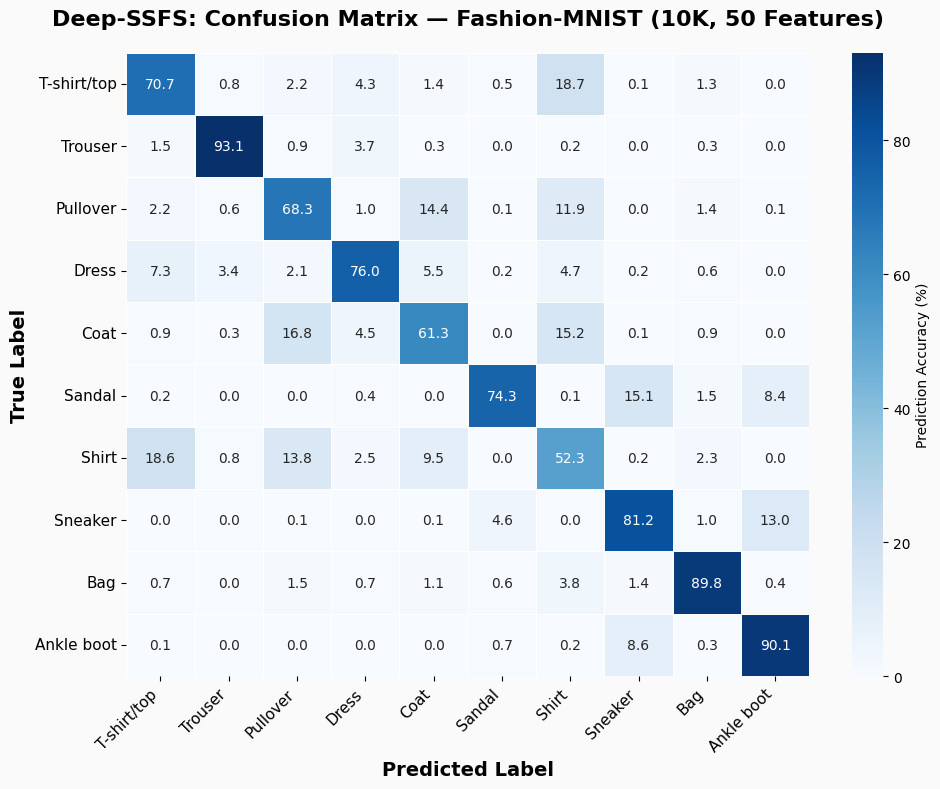

In [ ]:
# Load Fashion-MNIST and run 1-NN evaluation with the selected features.
(X_fmnist_train_raw, y_fmnist_train), (X_fmnist_test_raw, y_fmnist_test) = fashion_mnist.load_data()

X_fmnist_train_flat = X_fmnist_train_raw.reshape(-1, 784)
X_fmnist_test_flat  = X_fmnist_test_raw.reshape(-1, 784)

# Use 10,000 training samples to match the Session 5 final run.
X_train_10k = X_fmnist_train_flat[:10000]
y_train_10k = y_fmnist_train[:10000]

X_train_sel = X_train_10k[:, deep_fmnist]
X_test_sel  = X_fmnist_test_flat[:, deep_fmnist]

print("Fitting 1-NN classifier on 10K Fashion-MNIST samples...")
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_sel, y_train_10k)

y_pred = knn.predict(X_test_sel)
acc    = accuracy_score(y_fmnist_test, y_pred)
print(f"1-NN Test Accuracy: {acc * 100:.2f}%")


def plot_confusion_matrix(y_true, y_pred, class_labels,
                           title="Confusion Matrix", save_path=None):
    """
    Normalised confusion matrix (row-normalised to percentages).
    """
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

    fig, ax = plt.subplots(figsize=(10, 8), facecolor='#FAFAFA')
    sns.heatmap(
        cm_norm, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Prediction Accuracy (%)'},
        linewidths=0.5, linecolor='white', ax=ax
    )
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('True Label',      fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0,  fontsize=11)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_confusion_matrix(
    y_fmnist_test, y_pred, FASHION_LABELS,
    title="Deep-SSFS: Confusion Matrix — Fashion-MNIST (10K, 50 Features)",
    save_path=os.path.join(RESULTS_DIR, 'fmnist_confusion_matrix_10k.png')
)